In [83]:
# 3D interactivo (rotar/zoom): 'notebook' funciona en Jupyter/Cursor; 'widget' requiere ipympl compatible
try:
    import ipympl
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception as e:
    print(e)
    get_ipython().run_line_magic('matplotlib', 'notebook')  # interactivo: rotar, zoom (sin ipympl)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from itertools import product


# Finite-Dimensional Vector Spaces

### Linear combination

A *Linear combination* of a list $v_1, v_2, ..., v_m$ of vectors in $V$ is a vector of the form

$a_1 v_1 + a_2 v_2 + ... + a_m v_m$

where $a_1, a_2, ..., a_m \in \mathbb{R}$

For example, considering the vectors:

In [84]:
v = np.array([
    [0.5, -0.8, 0.2],
    [0.4, -0.2, 0.4],
    [0.1, 0.1, -0.9]])
v

array([[ 0.5, -0.8,  0.2],
       [ 0.4, -0.2,  0.4],
       [ 0.1,  0.1, -0.9]])

And a list of scalar values *a*

In [85]:
a = [0.1, 0.2, 0.3]
linear_combination = np.sum(a * v, axis=0)
linear_combination

array([ 0.1 , -0.18, -0.09])

This is a new vector that combines the information of the previous

## Span

The set of all linear combinations of a list of vectors $v_1, ..., v_m$ in V is called the *span* of $v_1, ..., v_m$, denoted by $span(v_1, ..., v_m)$

In [86]:
def plot_vectors(v, axes):
    for i in range(len(v)):
        axes[0].quiver(0, 0, 0, v[i,0], v[i,1], v[i,2], linewidth=2, label=f'v{i+1}')
    return axes

def config_r3(axes, title = 'Span de los vectores v en $\mathbb{R}^3$', min = -1, max = 1):
    axes[0].set_title(title)
    axes[0].set_xlabel('X')
    axes[0].set_ylabel('Y')
    axes[0].set_zlabel('Z')
    axes[0].set_xlim(min, max)
    axes[0].set_ylim(min, max)
    axes[0].set_zlim(min, max)
    axes[0].legend()
    return axes 

def plot_span(axes, v, min = -1, max = 1, step = 0.2):
    dim = len(v)
    steps = np.arange(min, max + step, step).tolist()
    coeffs = list(product(steps, repeat=dim))
    span = []
    for a in coeffs:
        # Coeficientes en columna (dim,1) para que a[i]*v[i] multiplique fila a fila; (dim,1)*(dim,3)->(dim,3)
        vec = (np.array(a).reshape(-1, 1) * v).sum(axis=0)
        span.append(vec)
    span = np.unique(np.array(span), axis=0)
    axes[0].scatter(span[:, 0], span[:, 1], span[:, 2], c='b', marker='o', label="Span de v", alpha=0.1)
    return axes

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_14460\4191894604.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


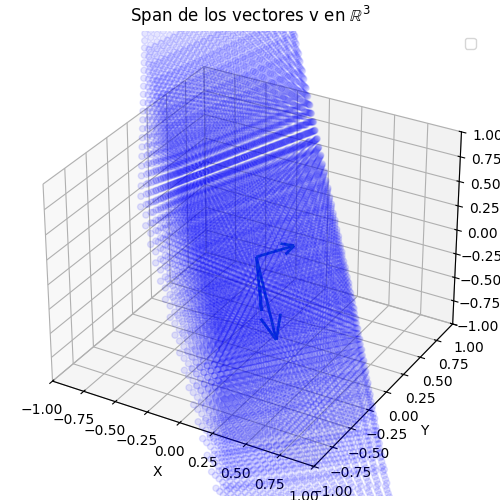

In [87]:
%matplotlib widget
fig = plt.figure(figsize=(5,5), constrained_layout=True)
axes = [fig.add_subplot(projection='3d')]
axes = config_r3(axes)
axes = plot_span(axes, v, min=-2, max=2)
axes = plot_vectors(v, axes)
plt.show()

## Linear independence

A list $v1, ..., v_m$ of vectors in $V$ is called *linearly independent* if the only choice of $a1,..., a_m \in \mathbb{R}$ that makes

$a_1v_1 + ... + a_mv_m = 0$

is $a_1,...,a_m = 0$ (Trivial solution)

Otherwise, the list of vectors is *linarly dependent*. 

In [88]:
v = np.array([[2, 3, 1], [1, -1, 2], [7, 3, 8]])
v

array([[ 2,  3,  1],
       [ 1, -1,  2],
       [ 7,  3,  8]])

This vectors are linearly dependent, we can obtain 0 combining them

In [89]:
2 *v[0] + 3 *v[1] - 1 *v[2]

array([0, 0, 0])

If we look at the span, we will see a flat subspace

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_14460\4191894604.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


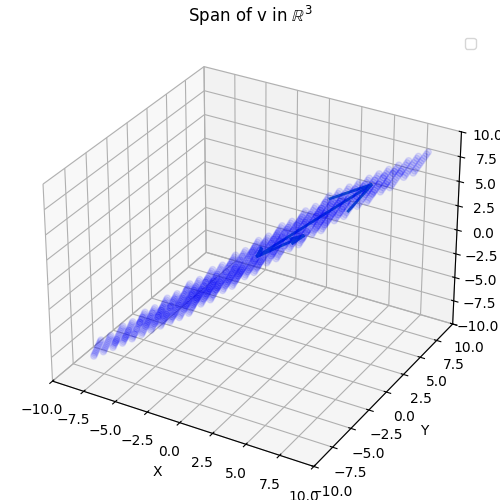

In [90]:
fig = plt.figure(figsize=(5,5), constrained_layout=True)
axes = [fig.add_subplot(projection='3d')]
axes = config_r3(axes, min=-10, max=10, title = "Span of v in $\mathbb{R}^3$")
axes = plot_vectors(v, axes)
axes = plot_span(axes, v)
plt.show()

Easy way to check if the vectors are Linearly independent:

$ if |v| \ne 0, \implies LI$

$ if |v| = 0 \implies LD$

$|v|$ is the determinant of a matrix builded by vectors $v$ as rows


In [91]:
np.linalg.det(v)

np.float64(0.0)

## Basis

A basis of $V$ is a list of vectors in $V$ that is linearly independent and spans $V$.

The list $(1,0,...,0), (0,1,...,0), (0,0,...,0), (0,0,...,1)$ is called the standard basis of $\mathbb{R}^N$

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_14460\4191894604.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


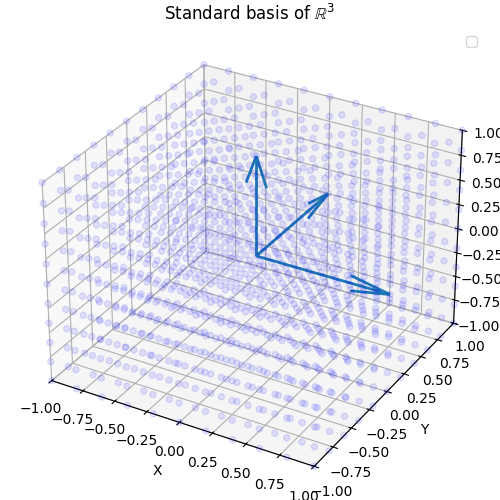

In [92]:
e = np.array([
    [1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]])
fig = plt.figure(figsize=(5,5), constrained_layout=True)
axes = [fig.add_subplot(projection='3d')]
axes = config_r3(axes, 'Standard basis of $\mathbb{R}^3$')
axes = plot_span(axes, e)
axes = plot_vectors(e, axes)
plt.show()

In [96]:
v = np.array([[1, 2], [3, 5]])
display(v)
display(np.linalg.det(v))

array([[1, 2],
       [3, 5]])

np.float64(-1.0000000000000004)

$v$ is linearly independent, and a span of $\mathbb{R}^2$. $v$ is a basis of $\mathbb{R}^2$.

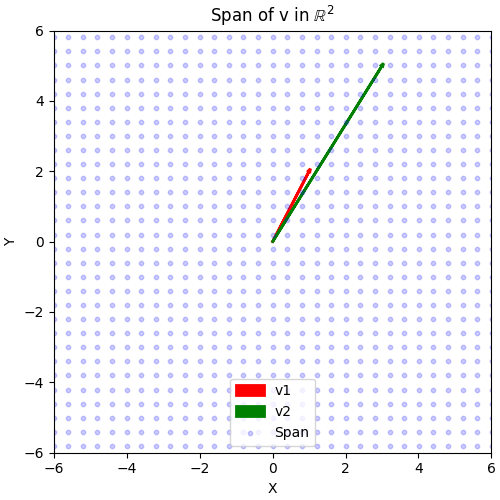

In [94]:
fig, axes = plt.subplots(figsize=(5,5), constrained_layout=True)

axes.arrow(0, 0, v[0,0], v[0,1], color='r', linewidth=2, label='v1',
        head_width=0.05, head_length=0.08)
axes.arrow(0, 0, v[1,0], v[1,1], color='g', linewidth=2, label='v2',
        head_width=0.05, head_length=0.08,)

alpha = np.linspace(-100, 100, 500)
beta = np.linspace(-100, 100, 500)
A, B = np.meshgrid(alpha, beta)
span_x = v[0,0]*A + v[1,0]*B
span_y = v[0,1]*A + v[1,1]*B
axes.scatter(span_x, span_y, color='b', alpha=0.2, s=10, label='Span')

axes.set_title('Span of v in $\mathbb{R}^2$')
axes.set_xlim(-6, 6)
axes.set_ylim(-6, 6)
axes.set_xlabel('X')
axes.set_ylabel('Y')
axes.legend()
plt.show()

C:\Users\Gabriel\AppData\Local\Temp\ipykernel_14460\4191894604.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


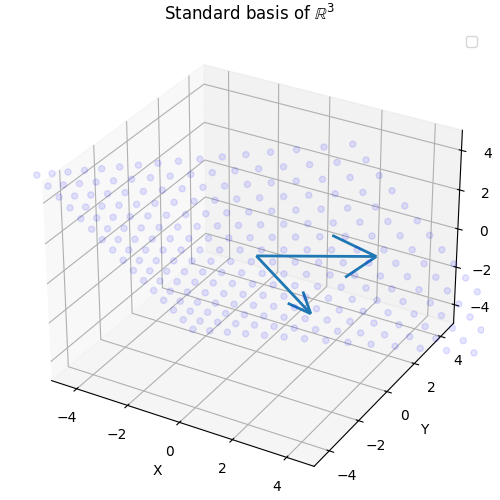

In [95]:
v = np.array([
    [1, 2,-4],
    [7,-5,6]])
fig = plt.figure(figsize=(5,5), constrained_layout=True)
axes = [fig.add_subplot(projection='3d')]
axes = config_r3(axes, min = -5, max = 5, title='Standard basis of $\mathbb{R}^3$')
axes = plot_span(axes, v, min = -1.5, max = 1.5)
axes = plot_vectors(v, axes)
plt.show()